# Final Project: Personal Finance Dashboard

---

You have spent the entire semester working with this dataset. You have explored it, cleaned it, summarized it, visualized it, joined it, analyzed it over time, and audited it for quality problems. This project is your chance to put all of that together.

In this notebook, you will build a personal finance summary — the kind of analysis a budgeting app might show you — using the cleaned semester transactions dataset.

**You will:**
- Load and prepare the cleaned dataset
- Compute ending balances for each account, starting from realistic opening balances
- Analyze total spending three ways: by payment method, by category, and by merchant
- Identify opportunities to cut costs and write a short budget recommendation
- Simulate 401(k) growth using compounding returns
- Reflect on what you found

**A note on AI tools:**  
You are encouraged to use GitHub Copilot Chat to help you write code in this project. That is a real professional skill. However, you are responsible for every line of code in this notebook. If Copilot suggests something, you need to understand what it does and verify that it produces the correct result. Copilot does not know the quirks of this specific dataset — you do.

---

## New in this notebook: `numpy`

This project introduces one new library: **numpy** (imported as `np`). You will use it in the 401(k) section to generate random numbers. Numpy is one of the foundational Python libraries for numerical computation — pandas itself is built on top of it.

The two numpy functions you need here are:

```python
np.random.seed(42)              # Set the seed so everyone gets the same random numbers
np.random.uniform(low, high)    # Generate one random number between low and high
```

Setting a seed means the random number generator starts from the same position every time. Everyone in the class will produce identical charts even though the numbers appear random.

---

## 0) Setup

Import the libraries you need and load the cleaned dataset.

Make sure `transactions.csv` and the remaining lookup files are in your data directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
# Load the cleaned transactions dataset and the lookup tables into DataFrames. 
# Data files should be in a 'data' subfolder: data/transactions.csv
# Your code here
df = pd.read_csv('data/transactions.csv')
ac = pd.read_csv('data/accounts.csv')
ca = pd.read_csv('data/categories.csv')
me = pd.read_csv('data/merchants.csv')
df_copy = df.copy()
ac_copy = ac.copy()
ca_copy = ca.copy()
me_copy = me.copy()


In [3]:
# Inspect the first few rows and confirm the shape of the DataFrames
# Your code here
print(df_copy.head(10))
print(df_copy.shape)

  transaction_id        date account_id transaction_type category_id  \
0       T0000001  2022-01-01        CHK           Income         PAY   
1       T0000002  2022-01-01        CHK         Transfer      RET401   
2       T0000003  2022-01-01     INV401         Transfer      RET401   
3       T0000617  2022-01-01        CHK          Expense        GROC   
4       T0000473  2022-01-03        CHK          Expense        PHON   
5       T0000618  2022-01-03        CC1          Expense         GAS   
6       T0000377  2022-01-03        CHK          Expense        RENT   
7       T0000569  2022-01-04        CC1          Expense        SUBS   
8       T0000425  2022-01-05        CHK          Expense        UTIL   
9       T0000521  2022-01-05        CHK          Expense         INS   

  merchant_id   amount  payment_method        description  
0   M_PAYROLL  4259.26  Direct Deposit           Paycheck  
1      M_401K  -255.56         Payroll  401k Contribution  
2      M_401K   255.56     

---

## 1) Prepare the Data

Before you can analyze anything, get the data into a usable shape.

You need to:
1. Parse the `date` column so Python treats it as a real date (not a string)
2. Join the lookup tables so you have names instead of IDs

In [4]:
# 1. Parse date column
# Your code here
if "date" in df_copy.columns:
    df_copy["date_parsed"] = pd.to_datetime(df_copy["date"], errors='coerce')
    
    # Count how many dates could not be converted
    bad_dates = df_copy["date_parsed"].isna().sum()

# Preview the original date values alongside the parsed dates
print(df_copy[["date", "date_parsed"]].head(12))

# 2. Join the lookup tables to add names
# Your code here
df_copy = df_copy.merge(me_copy, how="left", on="merchant_id")
df_copy = df_copy.merge(ca_copy, how="left", on="category_id")
df_copy = df_copy.merge(ac_copy, how="left", on="account_id")


          date date_parsed
0   2022-01-01  2022-01-01
1   2022-01-01  2022-01-01
2   2022-01-01  2022-01-01
3   2022-01-01  2022-01-01
4   2022-01-03  2022-01-03
5   2022-01-03  2022-01-03
6   2022-01-03  2022-01-03
7   2022-01-04  2022-01-04
8   2022-01-05  2022-01-05
9   2022-01-05  2022-01-05
10  2022-01-06  2022-01-06
11  2022-01-08  2022-01-08


In [5]:
# Verify: confirm date is parsed and name columns are present
# Your code here
print(df_copy.head(10))

  transaction_id        date account_id transaction_type category_id  \
0       T0000001  2022-01-01        CHK           Income         PAY   
1       T0000002  2022-01-01        CHK         Transfer      RET401   
2       T0000003  2022-01-01     INV401         Transfer      RET401   
3       T0000617  2022-01-01        CHK          Expense        GROC   
4       T0000473  2022-01-03        CHK          Expense        PHON   
5       T0000618  2022-01-03        CC1          Expense         GAS   
6       T0000377  2022-01-03        CHK          Expense        RENT   
7       T0000569  2022-01-04        CC1          Expense        SUBS   
8       T0000425  2022-01-05        CHK          Expense        UTIL   
9       T0000521  2022-01-05        CHK          Expense         INS   

  merchant_id   amount  payment_method        description date_parsed  \
0   M_PAYROLL  4259.26  Direct Deposit           Paycheck  2022-01-01   
1      M_401K  -255.56         Payroll  401k Contribution  20

---

## 2) Account Balances

This section computes the ending balance for each account.

### Opening balances

Every account starts somewhere. Use these opening balances:

| Account | Opening Balance | Notes |
|---|---|---|
| CHK | $500.00 | Checking account |
| SAV | $5,000.00 | Emergency fund. A common financial planning guideline is to keep 3–6 months of living expenses in an accessible savings account before investing. This is your safety net. |
| CC1 | $0.00 | No balance carried in |
| CC2 | $0.00 | No balance carried in |
| INV401 | $0.00 | Handled separately in Section 5 |

### How each account works

**Checking (CHK)**  
The hub of this financial picture. Money flows **in** as `Income` (paychecks, bonuses, side income). Money flows **out** as `Expense` (direct bills paid from checking like rent, utilities, groceries) and as `Transfer` (credit card payments and 401k contributions leaving the account). Include all three transaction types when computing the CHK balance.

**Savings (SAV)**  
This account only has interest transactions in the dataset — small income deposits each month. The $5,000 emergency fund grows slowly and steadily.

**Credit Cards (CC1 and CC2)**  
`Expense` transactions are charges (negative — you owe more). `Transfer` transactions are payments received from CHK (positive — balance reduced). The ending balance tells you what is still owed on each card.

> **Think before you code:** Charges increase what you owe, payments reduce it. Make sure the sign of your final credit card balance correctly reflects what is still owed — a negative remaining balance means money is still due.  Zero means you paid it all off. A positive balance would mean you overpaid and are owed money back.

In [6]:
# Checking account (CHK) — compute ending balance
# Include ALL transaction types (Income, Expense, Transfer)
# Start from the opening balance of $500.00

chk_opening = 500.00
print(df_copy["amount"][df_copy["account_id"] == "CHK"].sum())
# Your code here
chk_ending = chk_opening + df_copy["amount"][df_copy["account_id"] == "CHK"].sum()
print(chk_ending)

394866.6
395366.6


In [7]:
# Savings account (SAV) — compute ending balance
# Start from the opening balance of $5,000.00

sav_opening = 5000.00
print(df_copy["amount"][df_copy["account_id"] == "SAV"].sum())
# Your code here
sav_ending = sav_opening + df_copy["amount"][df_copy["account_id"] == "SAV"].sum()
print(sav_ending)


599.65
5599.65


In [23]:
# Credit card accounts (CC1 and CC2) — compute ending balance for each
# Both start at $0.00
# Expenses are charges (negative in dataset), Transfers are payments (positive)

# Your code here
expenses_cc1 = df_copy["amount"][(df_copy["account_id"] == "CC1") & (df_copy["transaction_type"] == "Expense")].sum()
print("CC1", expenses_cc1)
transfers_cc1 = df_copy["amount"][(df_copy["account_id"] == "CC1") & (df_copy["transaction_type"] == "Transfer")].sum()
print("CC1", transfers_cc1)
cc1_ending = 0.00 + expenses_cc1 + transfers_cc1
print(f"CC1 ending balance: {cc1_ending:.2f}")

expenses_cc2 = df_copy["amount"][(df_copy["account_id"] == "CC2") & (df_copy["transaction_type"] == "Expense")].sum()
print("CC2",expenses_cc2)
transfers_cc2 = df_copy["amount"][(df_copy["account_id"] == "CC2") & (df_copy["transaction_type"] == "Transfer")].sum()
print("CC2", transfers_cc2)
cc2_ending = 0.00 + expenses_cc2 + transfers_cc2
print(f"CC2 ending balance: {cc2_ending:.2f}")

CC1 -10867.415
CC1 14941.59
CC1 ending balance: 4074.17
CC2 -8595.325
CC2 7231.32
CC2 ending balance: -1364.01


In [9]:
# Print a clean account summary showing the ending balance for each account
# Format the values as dollar amounts
# Your code here
print(f"-- Account Summary --")
print(f"Checking: ${chk_ending:.2f}")
print(f"Saving: ${sav_ending:.2f}")
print(f"CC1: ${cc1_ending:.2f}")
print(f"CC2: ${cc2_ending:.2f}")

-- Account Summary --
Checking: $395366.60
Saving: $5599.65
CC1: $4074.17
CC2: $-1364.01


**What do you notice about the credit card balances?** Write 1–2 sentences.

*CC1 is in the positives with over $4000 in overpayment, while CC2 is over $1300 in debt.*

---

## 3) Total Spending: Three Views

Now you will analyze where the money went. You will look at spending from three angles — each one answers a different question.

### Before you begin: define "spending"

For all three charts, you want only `Expense` transactions. Exclude `Income` and `Transfer` rows.

Also exclude the `INV401` account — retirement contributions are not consumer spending, and you will analyze that account separately in Section 5.  In this dataset, all `INV401` transactions are `Transfer` type, so filtering for `Expense` will exclude them, but you can also explicitly exclude the account if you want to be sure.

Create a filtered DataFrame called `expenses` that you will reuse across all three charts. Convert the amounts to positive values — expenses are stored as negative numbers in this dataset, and positive values are easier to read in charts.

In [10]:
# Create the expenses DataFrame:
# - Only Expense transaction type
# - Exclude INV401 account
# - Convert amounts to positive values

# Your code here
ex = df_copy["amount"][(df_copy["account_id"] != "INV401") & (df_copy["transaction_type"] == "Expense")].abs()
ex.head(20)

3       62.29
4       85.00
5       89.19
6     1200.00
7       20.00
8      156.55
9      165.00
11      89.15
12      59.27
13       0.41
16      90.94
18      85.85
19      62.68
20      48.17
25      32.74
26      36.83
30     165.00
31     134.69
32      85.00
33      20.00
Name: amount, dtype: float64

### Chart 1: Spending by Payment Method — Credit Card vs. Checking

**Question:** How much of our total spending went on credit cards vs. paid directly from checking?

Group `expenses` by `account_id` and sum the amounts. CHK is direct checking spending. CC1 and CC2 are credit card spending.

Create a **bar chart** showing total spending by account. Include a title, labeled axes, and dollar formatting on the y-axis.

> **Reminder — dollar formatting on the y-axis:**
> ```python
> ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
> ```

In [11]:
# Summarize spending by account_id
# Your code here
summary = df_copy[df_copy["transaction_type"] == "Expense"].groupby("account_id")["amount"].sum().abs()
print(summary)

account_id
CC1    10867.415
CC2     8595.325
CHK    96898.770
Name: amount, dtype: float64


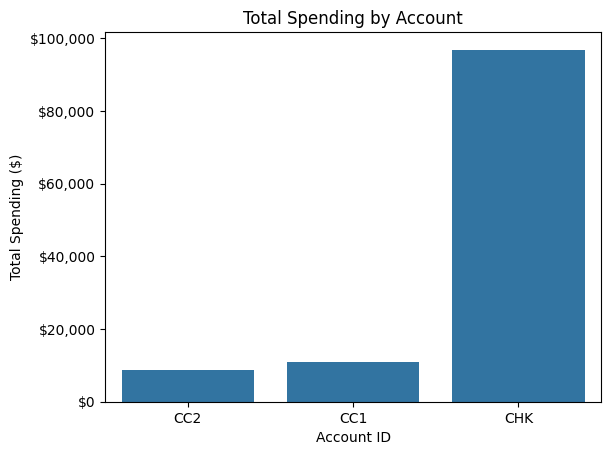

In [12]:
# Bar chart: total spending by account (CHK, CC1, CC2)
# Your code here
order = summary.sort_values(ascending=True).index
ax = sns.barplot(x=summary.index, y=summary.values, order=order)
plt.title("Total Spending by Account")
plt.xlabel("Account ID")
plt.ylabel("Total Spending ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()


**Interpretation (1–2 sentences):** What does this chart tell you about how this person pays for things?

*They mainly pay with their checking account rarely using credit cards.*

### Chart 2: Spending by Category — Top 10

**Question:** What are the biggest spending categories across all accounts?

Group `expenses` by `category name` and sum the amounts. Keep only the top 10 by total spend, sorted largest to smallest.

Create a **horizontal bar chart** — category labels are easier to read horizontally than vertically.

Include a title, labeled axes, and dollar formatting on the x-axis.

In [13]:
# Summarize spending by category name, keep top 10
# Your code here
ex_cat = df_copy[df_copy["transaction_type"] == "Expense"].groupby("category_name")["amount"].sum().abs().sort_values(ascending=False)
print(ex_cat.head(10))

category_name
Rent/Mortgage         61140.000
Groceries             15929.260
Insurance              8640.000
Gas/Transportation     8331.765
Utilities              6785.950
Dining Out             6078.075
Phone/Internet         4320.000
Entertainment          3889.630
Subscriptions          1084.000
Name: amount, dtype: float64


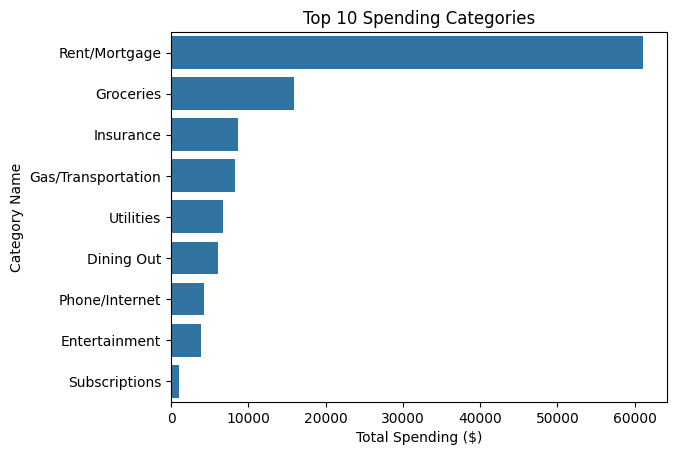

In [14]:
# Horizontal bar chart: top 10 spending categories
# Your code here
sns.barplot(x=ex_cat.head(10).values, y=ex_cat.head(10).index, orient="h")
plt.title("Top 10 Spending Categories")
plt.xlabel("Total Spending ($)")
plt.ylabel("Category Name")
plt.show()

**Interpretation (1–2 sentences):** What stands out to you about the category breakdown?

*Rent makes up for most of the expenses, with the next highest being groceries. Overall, there is less spending than anticipated compared to rent.*

### Chart 3: Spending by Merchant — Top 10

**Question:** Which specific merchants received the most money?

Group `expenses` by merchant name and sum the amounts. Keep only the top 10.

Create another **horizontal bar chart**.

> **Note:** Make sure your merchant join from Section 1 is complete. If you only have `merchant_id` at this point, go back and finish that join before continuing.

In [15]:
# Summarize spending by merchant name, keep top 10
# Your code here
group_ex_merchant = df_copy[df_copy["transaction_type"] == "Expense"].groupby("merchant_name")["amount"].sum().abs().sort_values(ascending=False)
print(group_ex_merchant.head(10))

merchant_name
FoxRiver Apartments    61140.000
QuickStop               8872.810
HealthPlus              8640.000
FreshMart               7140.010
CityPower               6785.950
BrightGas               6460.200
BrewHouse               6137.345
GigaNet                 4320.000
CoffeeCo                3889.630
MetroTransit            1871.565
Name: amount, dtype: float64


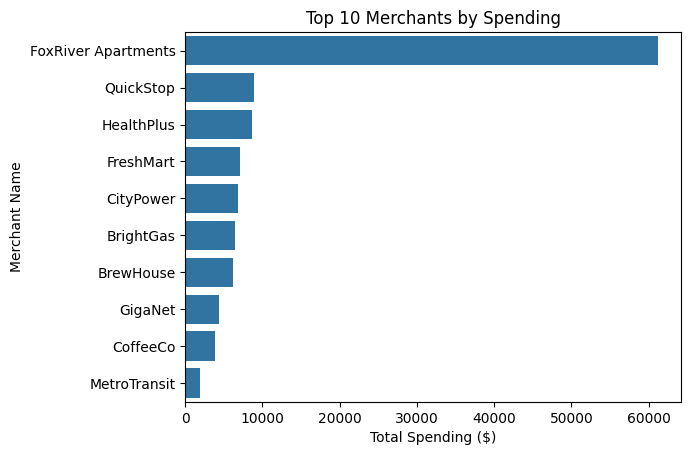

In [16]:
# Horizontal bar chart: top 10 merchants by spending
# Your code here
sns.barplot(x=group_ex_merchant.head(10).values, y=group_ex_merchant.head(10).index, orient="h")
plt.title("Top 10 Merchants by Spending")
plt.xlabel("Total Spending ($)")
plt.ylabel("Merchant Name")
plt.show()

**Interpretation (1–2 sentences):** Any surprises in the merchant list?

*There are no surprises in the merchant list as it mirrors the categories. The only slight surprise is how categories are split into multiple merchants.*

---

## 4) Budget Analysis

Now that you know where the money went, the next question is: *where could we spend less?*

This is what analysts actually do — not just describe the past, but use data to make recommendations.

### Step 4a — Monthly average spending by category

Compute the **monthly average spending** for each category. Totals are useful, but a monthly average is more practical for budgeting — it tells you what this person spends on a recurring basis.

To get there:
1. Group `expenses` by month (from `date`) and `category name`, and sum the amounts — this gives you total spending per category per month
2. Group that result by `category name` and take the mean — this gives you the average monthly spend per category

> **Hint:** You can do this in two steps with intermediate variables, or chain the groupby operations. Either approach is fine.

In [17]:
# Step 1: total spending per category per month
# Your code here
group_ex_month_cat = df_copy[df_copy["transaction_type"] == "Expense"].groupby([df_copy["date_parsed"].dt.to_period("M"), "category_name"])["amount"].sum().abs()
print(group_ex_month_cat.head(20))
# Step 2: average monthly spending per category
# Your code here
group_ex_month_cat_avg = group_ex_month_cat.groupby("category_name").mean().sort_values(ascending=False)
print(group_ex_month_cat_avg.head(10))

date_parsed  category_name     
2022-01      Dining Out              36.830
             Entertainment           62.680
             Gas/Transportation     137.770
             Groceries              360.970
             Insurance              165.000
             Phone/Internet          85.000
             Rent/Mortgage         1200.000
             Subscriptions           20.000
             Utilities              156.550
2022-02      Dining Out             188.845
             Entertainment           43.370
             Gas/Transportation     120.140
             Groceries              352.850
             Insurance              165.000
             Phone/Internet          85.000
             Rent/Mortgage         1200.000
             Subscriptions           20.000
             Utilities              134.690
2022-03      Dining Out              97.880
             Entertainment           96.340
Name: amount, dtype: float64
category_name
Rent/Mortgage         1273.750000
Groceries  

In [18]:
# Display monthly averages sorted from highest to lowest, formatted as dollar amounts
# Your code here
print("Average Monthly Spending by Category:", group_ex_month_cat_avg.apply(lambda x: f"${x:.2f}"))

Average Monthly Spending by Category: category_name
Rent/Mortgage         $1273.75
Groceries              $331.86
Insurance              $180.00
Gas/Transportation     $173.58
Utilities              $141.37
Dining Out             $129.32
Entertainment           $94.87
Phone/Internet          $90.00
Subscriptions           $23.06
Name: amount, dtype: str


### Step 4b — Budget Recommendation Memo

Look at your monthly averages. Identify **2–3 categories** where spending could reasonably be reduced.

Good candidates are **discretionary** categories — things like dining out, entertainment, or subscriptions — rather than fixed costs like rent, insurance, or utilities that are difficult to change.

For each category:
- State the current monthly average
- Propose a realistic reduced target
- Calculate the monthly savings and the annual savings (monthly × 12)

You may calculate the savings in code below, or do the math directly in your memo — your choice.

In [19]:
# Optional: calculate projected savings in code
# Your code here (or leave this cell empty and do the math in the memo)


### Budget Memo

**To:** Account Holder  
**From:** *Your name*  
**Subject:** Spending Reduction Recommendations  

Based on an analysis of transactions from January 2022 through December 2025, I recommend the following budget adjustments:

---

**Category 1: [Dining Out]**  
Current monthly average: $129.32   
Proposed monthly target: $100  
Monthly savings: $29.32  
Annual savings: $351.84  
Rationale: *Cutting $29.32 from dining out each month is reasonable due to it only being about 1-4 meals each month. These meals could instead be made at home for a much lower cost and healthier food.*

---

**Category 2: [Entertainment]**  
Current monthly average: $94.87 
Proposed monthly target: $50  
Monthly savings: $44.87  
Annual savings: $538.44  
Rationale: *This is a reasonable cut due to the non-necessity of the entertainment budget. Streaming services could be a replacement that would fall under subscriptions. There is also entertainment available online for free that makes it very reasonable to cut entertainment so much.*

---

**Category 3: [] (optional)**  
Current monthly average: $___  
Proposed monthly target: $___  
Monthly savings: $___  
Annual savings: $___  
Rationale: *Why is this a reasonable cut?*

---

**Total projected annual savings: $890.28**

---

## 5) 401(k) Growth Simulation

The `INV401` account tracks 401(k) contributions — money transferred from each paycheck into a retirement investment account. But contributions are only part of the story. The other part is **investment returns**: the account earns (or occasionally loses) money each month based on market performance.

In this section, you will simulate what that account looks like over time by applying a random monthly return to the growing balance. This is called **compounding** — each month's return is applied to the full balance, including all growth from prior months. The longer money stays invested, the more it compounds. This is why starting to save for retirement early matters so much.

### Assumptions
- Annual return: somewhere between **-2% and +10%** per year, randomized each month
- Monthly rate = annual rate ÷ 12
- Random seed is set to `42` so everyone gets the same result
- Account starts at $0

### How compounding works step by step

At the end of each month:
1. A new contribution arrives from payroll
2. The entire balance — including that new contribution — earns a return for the month

In code, one month looks like this:
```python
balance = (balance + contribution) * (1 + monthly_rate)
```

Repeat this for every month in chronological order and you get the account's full history.

---

### Step 5a — Get monthly 401(k) contributions

The `INV401` account receives contributions from CHK via payroll transfers. These are recorded as positive `Transfer` amounts on the `INV401` account.

Group `INV401` transactions by month using the `date` column and sum to get total contributions per month.

> **This code is provided — read it carefully and run it.**

In [24]:
# Get monthly 401(k) contributions from date-based monthly grouping
inv401 = df[df['account_id'] == 'INV401'].copy()

inv401['date'] = pd.to_datetime(inv401['date'], errors='coerce')

contributions = (
    inv401
    .groupby(inv401['date'].dt.to_period('M'))['amount']
    .sum()
    .reset_index()
    .rename(columns={'date': 'year_month', 'amount': 'contribution'})
)

print(f"Months with contributions: {len(contributions)}")
print(f"Monthly range: ${contributions['contribution'].min():.2f} — ${contributions['contribution'].max():.2f}")
contributions.head()

Months with contributions: 48
Monthly range: $511.12 — $900.00


,year_month,contribution
0,2022-01,766.68
1,2022-02,511.12
2,2022-03,511.12
3,2022-04,511.12
4,2022-05,511.12


### Step 5b — Simulate the growing balance

Now simulate the account month by month. The loop walks through every month in order, adds the contribution, applies a random return, and records the new balance.

We also track `total_contributed` separately — the cumulative dollars deposited with no growth. This is the baseline for the chart in the next step.

> **This code is provided — read it carefully and run it.**

In [25]:
# Set the random seed — everyone gets the same result
np.random.seed(42)

balance = 0.0
balances = []
cumulative_contributions = []
total_contributed = 0.0

for _, row in contributions.iterrows():
    contribution = row['contribution']

    # Random annual return between -2% and +10%, converted to a monthly rate
    annual_return = np.random.uniform(-0.02, 0.10)
    monthly_rate = annual_return / 12

    # Add contribution then apply the monthly return to the full balance
    balance = (balance + contribution) * (1 + monthly_rate)
    total_contributed += contribution

    balances.append(round(balance, 2))
    cumulative_contributions.append(round(total_contributed, 2))

# Add results to the contributions DataFrame
contributions['account_value'] = balances
contributions['total_contributed'] = cumulative_contributions

# Keep a 'date' column for charting
contributions['date'] = contributions['year_month'].dt.to_timestamp()

# Summary
final_value = contributions['account_value'].iloc[-1]
final_contributed = contributions['total_contributed'].iloc[-1]
print(f"Total contributions made: ${final_contributed:,.2f}")
print(f"Final account value:      ${final_value:,.2f}")
print(f"Growth from returns:      ${final_value - final_contributed:,.2f}")

Total contributions made: $29,400.00
Final account value:      $31,407.41
Growth from returns:      $2,007.41


### Step 5c — Chart: What you put in vs. what it is worth

Create a line chart with **two lines** on the same axes:
- **Total contributed** — cumulative dollars deposited, with no investment growth applied
- **Account value** — actual balance after compounding returns

The gap between the two lines is the value created purely by investment returns. That gap is the whole point of investing for retirement.

Your chart should have:
- A descriptive title
- Labeled axes
- Dollar formatting on the y-axis
- Readable date labels on the x-axis
- A legend identifying each line

> **Hint:** Plot two lines on the same axes by calling `ax.plot()` twice with the same `ax`. Pass a `label=` argument to each line so the legend can identify them, then add `ax.legend()` after both lines are drawn.
>
> Example structure:
> ```python
> fig, ax = plt.subplots(figsize=(12, 5))
> ax.plot(contributions['date'], contributions['total_contributed'], label='Total Contributed')
> ax.plot(contributions['date'], contributions['account_value'], label='Account Value')
> ax.legend()
> ```

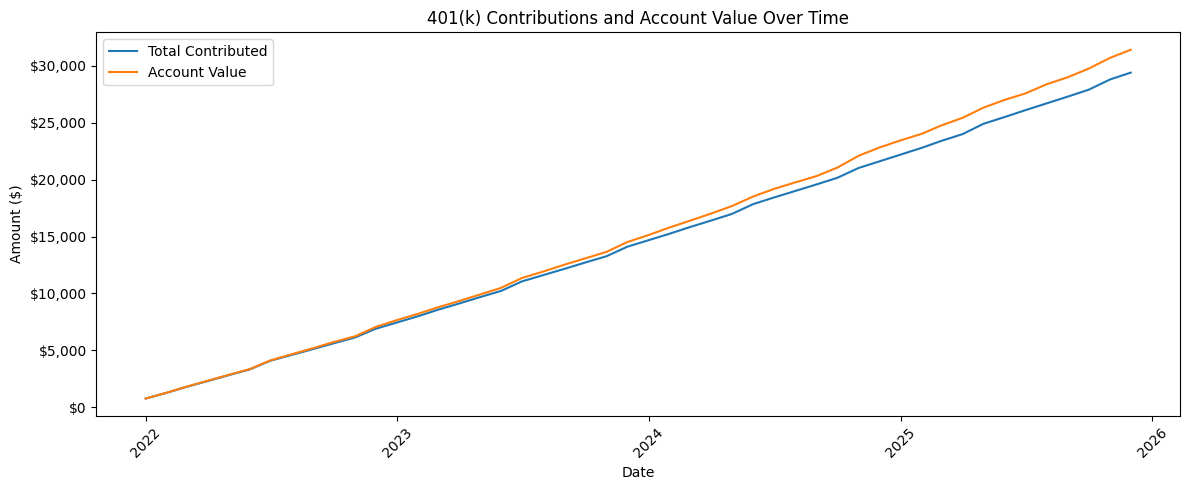

In [22]:
# Line chart: total contributed vs. account value over time
# Your code here
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(contributions['date'], contributions['total_contributed'], label='Total Contributed')
ax.plot(contributions['date'], contributions['account_value'], label='Account Value')
ax.set_title('401(k) Contributions and Account Value Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Amount ($)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation (2–3 sentences):** What do you notice about the gap between the two lines over time? How does this connect to the idea of starting to save for retirement early?

*The gap between the projected lines gets progressively wider as time goes by. This supports saving for retirement early, as the earlier you start, the more distance between the lines, and therefore, wealth can grow.*

---

## 6) Final Reflection

Answer the following questions. A few sentences each is fine.

1. **What was the most interesting thing you found in this dataset over the course of the semester?** It does not have to be from this notebook.


2. **Where did you use GitHub Copilot in this project?** What did it help with, and did you have to correct or verify anything it suggested?


3. **Looking at the full picture — income, spending, savings, credit cards, and retirement — how would you describe the financial health of this account holder?** Use at least two specific numbers from your analysis to support your answer.

**1. Most interesting finding this semester:**

*The most interesting thing I found in the dataset was the transactions that moved money around. I knew it happened, I just never looked at a detailed report of it happening alongside the other transactions.*

**2. How I used GitHub Copilot:**

*I used GitHub Copilot in this project to finish the code I was writing. I did have to correct the code sometimes due to it making up variables. Verifying it was also relatively easy, as it was straightforward, and I could track the logic solidly.*

**3. Overall financial health assessment:**

*The financial health of the account holder is quite good. They do not spend a lot of money each month. Dining out averaged $129.32 monthly, and entertainment was $94.87. Their income far surpasses their expenses, correlating to good savings along with a healthy growth of their 401 (k).*

---

## Submission

When you are finished:

1. Save your notebook
2. Restart the kernel and run all cells from top to bottom (**Kernel → Restart & Run All**) to confirm everything executes without errors
3. Push your completed notebook to your GitHub Classroom repository
4. Submit the repository link in Blackboard

Good work this semester!